In [1]:
# Import all the required modules and classes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Loading the csv file.**

Note that The encoding 'latin-1' is used for compatibility purposes as this dataset may contain special characters. In short, to avoid UnicodeDecodeError errors that occur when a file contains characters not compatible with the default (usually UTF-8) encoding.

In [2]:
df = pd.read_csv("C:\\Users\\sanja\\anaconda_projects\\OIBSIP\\Task_1_Email_Spam_Detection\\Data\\spam.csv", encoding='latin1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## STEP 1: Data Exploration.
 Understanding the structure and information of the dataset is crucial for smooth downstream processes

In [3]:
print("The number of rows and columns in the dataframe:")
df.shape

The number of rows and columns in the dataframe:


(5572, 5)

In [4]:
print("The concise summary of the dataframe:")
df.info()

The concise summary of the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
print("The column names are:")
df.columns

The column names are:


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [6]:
print("The number of Spam vs Ham mails:")
print(df['v1'].value_counts())

The number of Spam vs Ham mails:
v1
ham     4825
spam     747
Name: count, dtype: int64


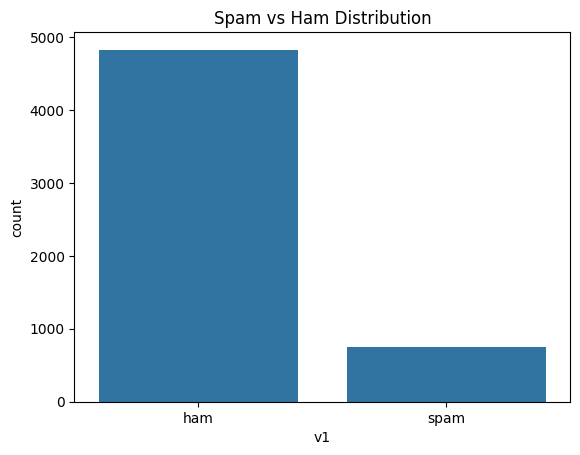

In [7]:
# Visualization
sns.countplot(x='v1', data=df)
plt.title('Spam vs Ham Distribution')
plt.show()

## STEP 2: Data Cleaning

In [8]:
# Drop the unwanted columns
columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
clean_df = df.drop(columns=columns_to_drop)

# Renaming the columns accordingly
clean_df.columns = ['Label', 'Email']
clean_df.head()

,Label,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Encoding Spam & Ham
encoder = LabelEncoder()
clean_df['Label'] = encoder.fit_transform(clean_df['Label'])
clean_df.head()

,Label,Email
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Inspecting missing values
miss_val = clean_df.isnull().value_counts()
print(f'The missing values in the dataframe: {miss_val}') # No missing values found

The missing values in the dataframe: Label  Email
False  False    5572
Name: count, dtype: int64


In [11]:
# Handling duplicate values

# print("The number of duplicates:")
dup = clean_df.duplicated().sum()
print(f'The number of duplicate rows : {dup}')  #There are 403 duplicate rows

The number of duplicate rows : 403


In [12]:
clean_df.drop_duplicates(inplace=True)
cleaned = clean_df.duplicated().sum()  #Now, there is none.
print(f'The number of duplicates after removing them: {cleaned}')

The number of duplicates after removing them: 0


In [13]:
clean_df.shape #From 5572 rows and 5 columns -> 5169 rows and 2 columns

(5169, 2)

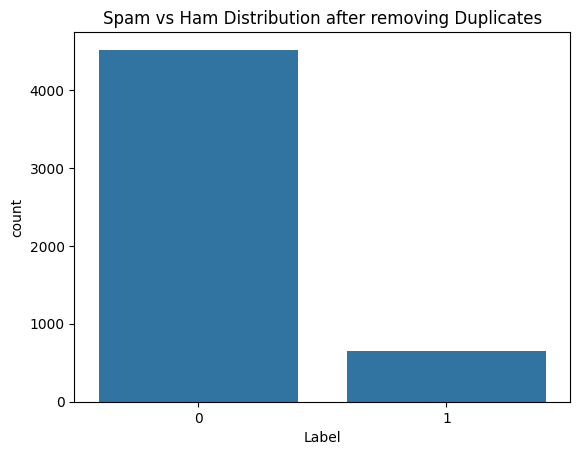

In [14]:
# Visualization after removing duplicates
sns.countplot(x='Label', data=clean_df)
plt.title('Spam vs Ham Distribution after removing Duplicates')
plt.show()

## STEP 3: Exploratory Data Analysis

In [15]:
clean_df['Label'].value_counts()

Label
0    4516
1     653
Name: count, dtype: int64

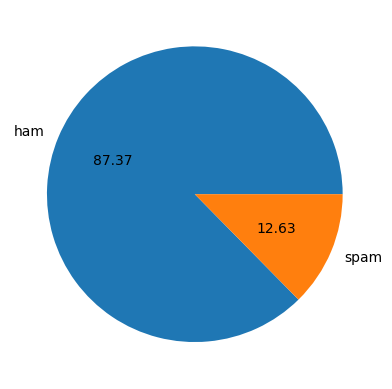

In [16]:
# Visualization
plt.pie(clean_df['Label'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()


Data is imbalanced.

In [17]:
# Email Length Analysis (words, characters & sentences)
# Character counts

clean_df['Email_length'] = clean_df['Email'].apply(len)
clean_df.head()

,Label,Email,Email_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
# Comparison between spam and ham

clean_df.groupby('Label')['Email_length'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
0,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
1,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


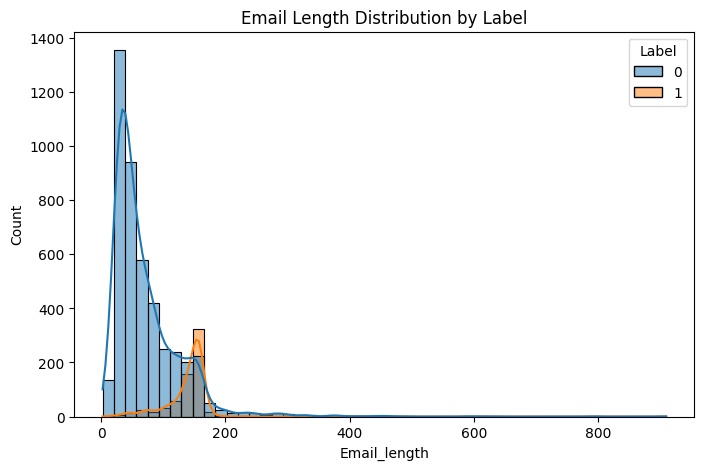

In [19]:
# Visualization
plt.figure(figsize=(8,5))
sns.histplot(data=clean_df, x='Email_length', hue='Label', bins=50, kde=True)
plt.title("Email Length Distribution by Label")
plt.show()

In [20]:
# Word counts

clean_df['Word_count'] = clean_df['Email'].apply(lambda x: len(nltk.word_tokenize(x)))
clean_df.head()

,Label,Email,Email_length,Word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [21]:
# Comparison of word count

clean_df.groupby('Label')['Word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
0,4516.0,17.123782,13.493970,1.0,8.0,13.0,22.0,220.0
1,653.0,27.667688,7.008418,2.0,25.0,29.0,32.0,46.0


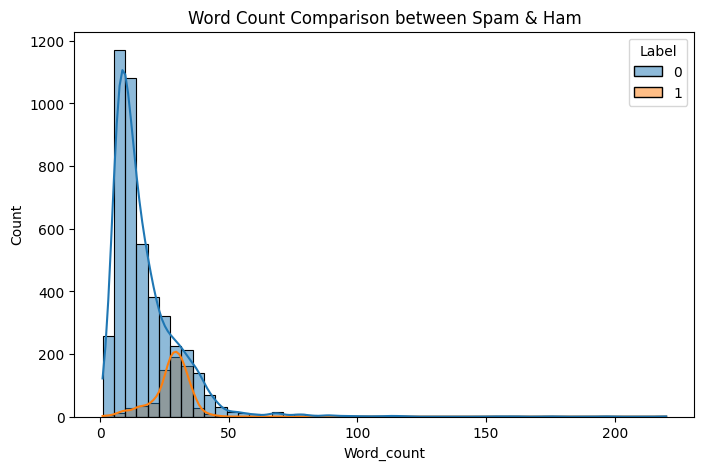

In [22]:
# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(data=clean_df, x='Word_count', hue='Label', bins=50, kde=True)
plt.title("Word Count Comparison between Spam & Ham")
plt.show()

In [23]:
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sanja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sanja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
# Sentence counts

clean_df['Sentence_count'] = clean_df['Email'].apply(lambda x: len(nltk.sent_tokenize(x)))
clean_df.head()

,Label,Email,Email_length,Word_count,Sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
# Comparison of Sentence count

clean_df.groupby('Label')['Sentence_count'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
0,4516.0,1.820195,1.383657,1.0,1.0,1.0,2.0,38.0
1,653.0,2.970904,1.488425,1.0,2.0,3.0,4.0,9.0


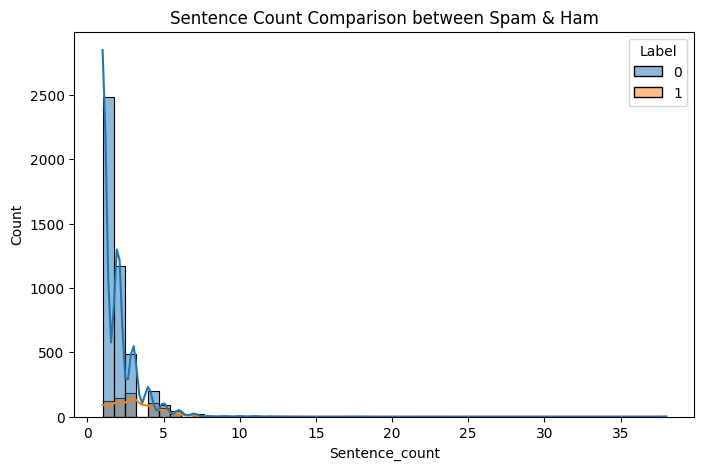

In [26]:
# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(data=clean_df, x='Sentence_count', hue='Label', bins=50, kde=True)
plt.title("Sentence Count Comparison between Spam & Ham")
plt.show()

In [27]:
# Comparison between characters, words & sentences in Ham

clean_df[clean_df['Label'] == 0][['Email_length', 'Word_count', 'Sentence_count']].describe()

,Email_length,Word_count,Sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# Comparison between characters, words & sentences in spam

clean_df[clean_df['Label'] == 1][['Email_length', 'Word_count', 'Sentence_count']].describe()

,Email_length,Word_count,Sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [29]:
# Compute the Correlation between text features
numeric_df = clean_df[['Email_length', 'Word_count', 'Sentence_count']]
corr_matrix = numeric_df.corr()
corr_matrix.head()

,Email_length,Word_count,Sentence_count
Email_length,1.000000,0.965760,0.624139
Word_count,0.965760,1.000000,0.679971
Sentence_count,0.624139,0.679971,1.000000


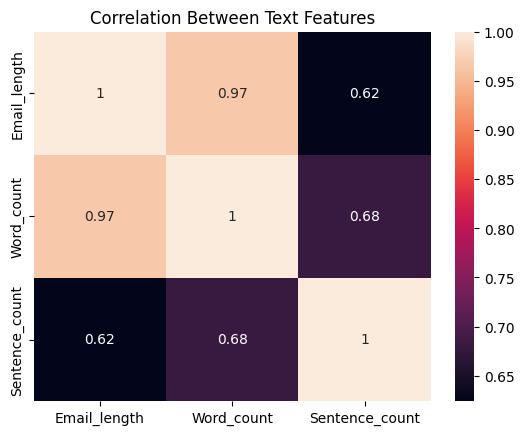

In [30]:
# Visualization
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Between Text Features")
plt.show()

In this plot we can see that, emails with more characters almost always have more words.
Longer emails often have more sentences, but not always.
More words usually mean more sentences, but style varies.

In [31]:
# Compute the correlation of text features with Ham & Spam
num_df = clean_df[['Label', 'Email_length', 'Word_count', 'Sentence_count']]
corr_matrix1 = num_df.corr()
corr_matrix1.head()

,Label,Email_length,Word_count,Sentence_count
Label,1.000000,0.384717,0.262912,0.263939
Email_length,0.384717,1.000000,0.965760,0.624139
Word_count,0.262912,0.965760,1.000000,0.679971
Sentence_count,0.263939,0.624139,0.679971,1.000000


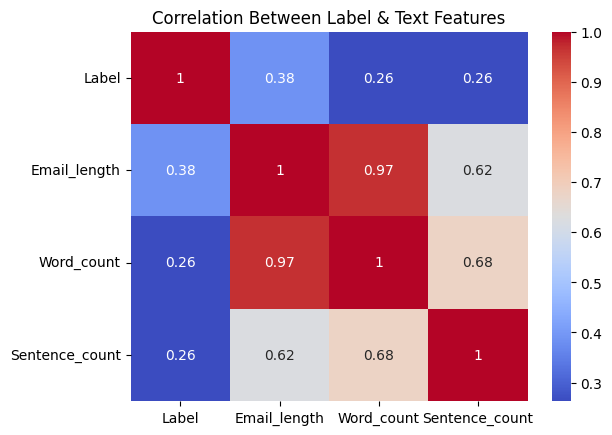

In [32]:
# Visualization
sns.heatmap(corr_matrix1, annot=True, cmap='coolwarm')
plt.title("Correlation Between Label & Text Features")
plt.show()

In this plot we can see that, emails with more characters has higher correlation with Label than number word and sentences in emails.

## STEP 4: Data/Text Preprocessing

*Preprocessing helps models “see” patterns*

Text preprocessing was applied prior to vectorization to ensure consistent token normalization. The vectorizers were fitted exclusively on the preprocessed training data and applied to the test set to avoid data leakage.


In [33]:
# Function to preprocess text

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # 3. Tokenization
    tokens = nltk.word_tokenize(text)

    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Stemming
    tokens = [ps.stem(word) for word in tokens]


    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
# Adding it as a new column to the dataframe
clean_df['Preprocessed_email'] = clean_df['Email'].apply(preprocess_text)
clean_df.head()

,Label,Email,Email_length,Word_count,Sentence_count,Preprocessed_email
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


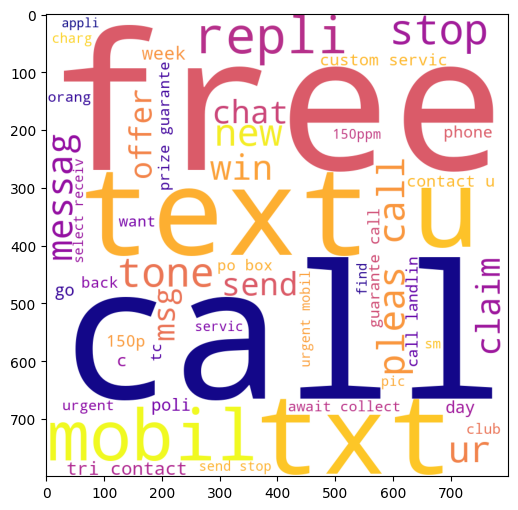

In [35]:
# Visualization of preprocessed emails in wordcloud
# Top 50 words for Spam emails

wc = WordCloud(width=800, height=800, min_font_size=10, background_color='white', max_words=50, colormap='plasma')
spam_wc = wc.generate(clean_df[clean_df['Label']==1]['Preprocessed_email'].str.cat(sep = " "))
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)

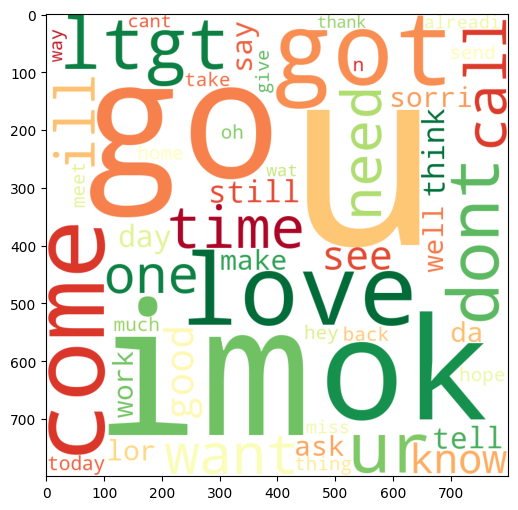

In [42]:
# Top 50 words for Ham emails

wc = WordCloud(width=800, height=800, min_font_size=10, background_color='white', max_words=50, colormap='RdYlGn')
ham_wc = wc.generate(clean_df[clean_df['Label']==0]['Preprocessed_email'].str.cat(sep = " "))
plt.figure(figsize=(15, 6))
plt.imshow(ham_wc)

## STEP 5: Train-Test Split

*Why apply preprocess again to the split data in ML?*

Because steps like vectorization and vocabulary creation learn from the data distribution, and including test data leads to data leakage and over-optimistic performance. Rule-based steps(above preprocessing steps) doesn't learn anything, but for consistency and to avoid accidental leakage in later stages like vectorization, I followed a clean pipeline where text preprocessing was applied again to the split.

In [43]:
# Define features and labels
X = clean_df['Email'] # input text
y = clean_df['Label'] # spam/ham

In [44]:
# A. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
# X_train
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4135
Testing samples: 1034


In [46]:
# B. Apply preprocessing on training data
X_train_processed = X_train.apply(preprocess_text)

In [47]:
# On testing data
X_test_processed = X_test.apply(preprocess_text)

## STEP 6: Vectorization

*ML models cannot understand text. They only understand numbers. So, we need to convert text → numbers.*

**Applied on preprocessed data to avoid data leakage**

**Why Two Vectorization Methods Were Used**

- To empirically evaluate how different text representations affect model performance.
- To select the most suitable vectorization approach based on task-specific evaluation metrics rather than assumptions.


In [48]:
# CountVectorizer
cv = CountVectorizer()

X_train_cv = cv.fit_transform(X_train_processed)
X_test_cv = cv.transform(X_test_processed)


In [49]:
print(X_train_cv.shape)
print(X_test_cv.shape)

(4135, 6906)
(1034, 6906)


In [50]:
# TF-IDF
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train_processed)
X_test_tfidf = tfidf.transform(X_test_processed)

In [51]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 6906)
(1034, 6906)


## STEP 7: Model Building 

Used Naive Bayes because spam detection = word probability problem and Naive Bayes models exactly this.

In [52]:
# MultinomialNB for CountVectorizer
mnb_count = MultinomialNB()
mnb_count.fit(X_train_cv, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [53]:
# Predictions
y_pred_cv = mnb_count.predict(X_test_cv)

In [54]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred_cv)
print(accuracy)

0.9796905222437138


In [55]:
# Full classification report
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.95      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



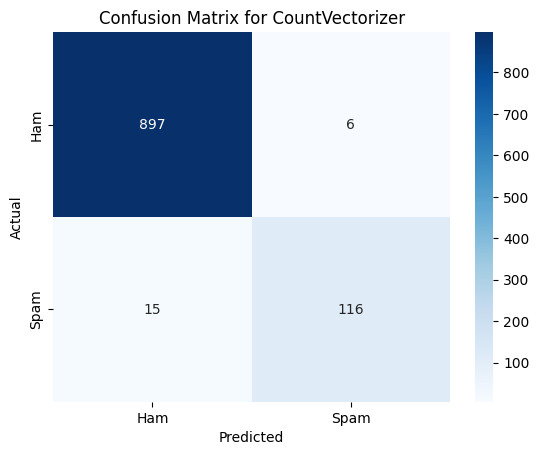

In [56]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cv)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for CountVectorizer")
plt.show()

In [57]:
# MultinomialNB for TfidfVectorizer 
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [58]:
# Predictions
y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

In [59]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred_tfidf)
print(accuracy)

0.9632495164410058


In [60]:
# Full classification report
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



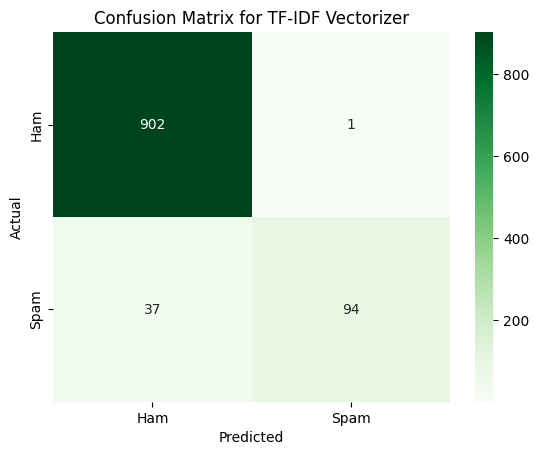

In [61]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tfidf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for TF-IDF Vectorizer")
plt.show()

**Comparison of Vectorization Techniques**

Two text vectorization techniques were evaluated for the email spam detection task: **CountVectorizer** and **TF-IDF Vectorizer**, both combined with a Multinomial Naive Bayes classifier.

**Performance Summary**

| Metric                       | CountVectorizer | TF-IDF Vectorizer |
| ---------------------------- | --------------- | ----------------- |
| Accuracy                     | **0.98**        | 0.96              |
| Spam Recall                  | **0.89**        | 0.72              |
| Spam F1-Score                | **0.92**        | 0.83              |
| Ham Recall                   | 0.99            | **1.00**          |
| False Negatives (Spam → Ham) | **15**          | **37**            |
| Precision                    | 0.95            | **0.99**          |


**Key Observations**

- **CountVectorizer** achieved significantly higher recall and F1-score for the spam class.
- **TF-IDF** showed perfect precision for spam but failed to identify a large number of spam emails.
- Since spam detection prioritizes minimizing false positives (missed ham), precision was treated as a more important metric than overall accuracy and recall.

*Final Vectorizer Selection Logic*

**TF-IDF Vectorizer** was selected as the final vectorization method because:
- It captured the importance of a word in an email compared to all emails.
- When combined with Multinomial Naive Bayes, it achieved superior precision.
- It reduced the number of dangerous false positives compared to CountVectorizer.

*Saving The Model for Streamlit*

In [62]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(mnb_tfidf, f)

# Save TF-IDF vectorizer
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)